In [29]:
import pandas as pd
import numpy as np

In [30]:
df=pd.read_csv("powerplant_data.csv")
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [31]:
# AT -- temperature
# V -- Vaccum
# AP -- Pressure
# RH -- Humidity

# PE -- Produced Energy Output

In [32]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [33]:
X=df.drop("PE" , axis=1)
y=df["PE"]

In [34]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [35]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [36]:
# Split our Data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test=train_test_split(
    X,y,test_size=0.2, random_state=42
)

In [37]:
X_test

,AT,V,AP,RH
2513,29.70,57.35,1005.63,57.35
9411,25.71,71.64,1008.85,77.31
8745,17.83,44.92,1025.04,70.58
9085,9.46,41.40,1026.78,87.58
4950,29.90,64.79,1016.90,48.24
...,...,...,...,...
7204,20.46,51.43,1010.06,83.79
1599,29.70,67.17,1007.31,66.56
5697,14.64,39.58,1011.46,71.90
350,29.47,71.32,1008.07,67.00


In [38]:
df.shape

(9568, 5)

In [39]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [40]:
X_test_scaled

array([[ 1.34499288,  0.23869298, -1.28658067, -1.10532538],
       [ 0.81095912,  1.36269098, -0.74140656,  0.26485915],
       [-0.2437241 , -0.73900436,  1.99970178, -0.19713193],
       ...,
       [-0.67068342, -1.15902881, -0.29951077, -0.10651852],
       [ 1.31420898,  1.33752097, -0.87346737, -0.44288647],
       [-0.2611237 , -0.27021304,  0.37433797,  1.10646548]],
      shape=(1914, 4))

In [41]:
import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
# since in y_train we don't have an array, so we access the series values directly
# .view() --> changing the dimensions, .view(-1,1) || -1 --> number of rows, 1 --> number of columns

X_test_tensor=torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [42]:
y_train.shape
# but when Pytorch needs tensors the expected shape of tensors in terms of y_train is (n,1)
# our data y_train is stored in 1D, to convert [1,2,3,4,5....] into [[1],[2],[3],[4],[5].....] we used .view(-1,1)
# -1 --> automatically detects the rows,  -1 is automatically replaced by 7654 and 1 is our number of columns
# all these 4 tensors are stored in the RAM of our computer 

(7654,)

In [43]:
type(X_train_scaled)

numpy.ndarray

In [44]:
type(y_train)

pandas.core.series.Series

In [45]:
from torch.utils.data import TensorDataset, DataLoader

# train_dataset=TensorDataset(in_features,out_features)
train_dataset=TensorDataset(X_train_tensor, y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [46]:

train_loader=DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader=DataLoader(test_dataset, batch_size=32)

# Deep Learning

In [47]:
# Build our ANN Model

class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
        # 1st hidden layer 
        nn.Linear(X_train.shape[1],6),   # to compute linear combination(z)
        nn.ReLU(),

        # 2nd hidden Layer
        nn.Linear(6,6),
        nn.ReLU(),

        # Output layer
        nn.Linear(6,1)
        )  
    
    def forward(self, x):
        return self.model(x)

# we don't need to write function for BP because BP is automatically handled by PyTorch
# later, during training of NN, we will calculate loss function and through it we will use loss.backward()
# Inside Pytorch, Autograd handles backward propagation, it is a automatic gradient computation engine

In [48]:
import torch.optim as optim

model=ANN()

# we can customize loss,optimizer
# since we are solving Regression problem so we will use MSE as the loss function
# based on the MSE criterion we will decide how our gradient descent curve will look like
# if MSE is decreasing then our loss function is minimising

criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())

In [49]:
# Train the ANN
train_losses=[]

best_val_loss=float("inf")

val_losses=[]
epochs=100

for epoch in range(epochs):
    model.train()               # in this mode our model will adjust weights on seeing new data
    running_loss=0.0            #total training loss of 1 epoch
    for xb,yb in train_loader:   # train_loader is giving us every batch where xb=features of 1 batch, yb=labels of 1 batch

        optimizer.zero_grad()     # to convert old grads to zero so that fresh grads are computed for new batch
        
        outputs=model(xb)        # Forward Propagation....... predicted output of this batch
        loss=criterion(outputs,yb)
        loss.backward()   # back propagation...... compute gradients
        optimizer.step()  # params update

        running_loss+=loss.item()      # using .item() we are converting the tensor loss => py float, running_loss is calculating loss of all Batches
        # training_losses = avg loss per batch for 1 epoch = running_loss / no. of batches
        # loss keeps on minimizing per every epoch
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)
    # validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad():   # telling pytorch of no gradients computation
        for xb,yb in test_loader:
            outputs=model(xb)
            loss=criterion(outputs,yb)
            running_val_loss+=loss     # during testing we don't have BP(no need of calculating gradient) because weights(learnable params) are already adjusted during training
        
        epoch_val_loss=running_val_loss/len(test_loader)
        val_losses.append(epoch_val_loss)

        print(f"epoch {epoch+1}/{epochs} ===> train loss = {epoch_train_loss} & val loss={epoch_val_loss}")

        if(epoch_val_loss<best_val_loss):
            best_val_loss=epoch_val_loss
            torch.save(model.state_dict(),"best_model.pt") # .pt or .pth extensions

epoch 1/100 ===> train loss = 205949.24921875 & val loss=$204351.90625
epoch 2/100 ===> train loss = 199516.73600260416 & val loss=$191611.015625
epoch 3/100 ===> train loss = 177593.76302083334 & val loss=$160141.078125
epoch 4/100 ===> train loss = 138030.87018229166 & val loss=$114677.1015625
epoch 5/100 ===> train loss = 91935.93929036458 & val loss=$71036.6328125
epoch 6/100 ===> train loss = 55285.4958984375 & val loss=$42153.984375
epoch 7/100 ===> train loss = 33857.99750162761 & val loss=$26795.634765625
epoch 8/100 ===> train loss = 22670.14296468099 & val loss=$18830.857421875
epoch 9/100 ===> train loss = 16872.889506022137 & val loss=$14592.99609375
epoch 10/100 ===> train loss = 13500.002341715495 & val loss=$11854.6240234375
epoch 11/100 ===> train loss = 11039.889388020832 & val loss=$9593.107421875
epoch 12/100 ===> train loss = 8851.104231770832 & val loss=$7529.9951171875
epoch 13/100 ===> train loss = 6862.876035563151 & val loss=$5685.9677734375
epoch 14/100 ===> t

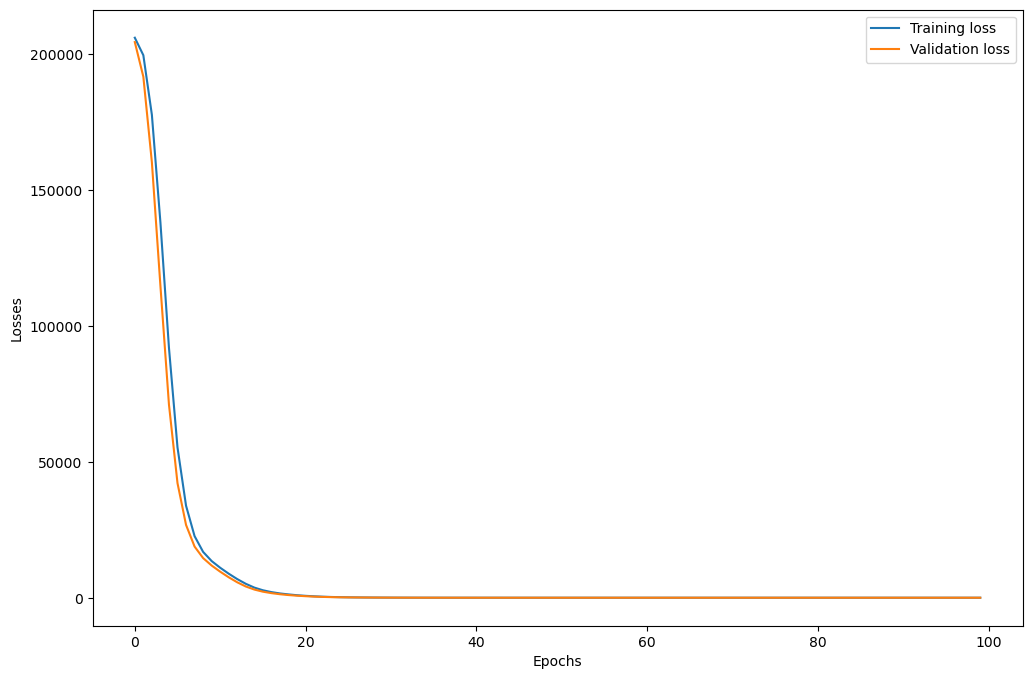

In [50]:
import matplotlib.pyplot as plt

loss_df=pd.DataFrame({
    "Training loss":train_losses,
    "Validation loss":val_losses,
})
plt.figure(figsize=(12,8))
plt.plot(loss_df["Training loss"], label="Training loss")
plt.plot(loss_df["Validation loss"], label="Validation loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [51]:
# Loading the best model
model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [52]:
# Evaluate our model
model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=criterion(train_preds,y_train_tensor)
    test_mse_loss=criterion(test_preds,y_test_tensor)
print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 20.780519485473633
Testing MSE: 19.125167846679688


In [53]:
from sklearn.metrics import r2_score

print("r2 score:",r2_score(y_test,test_preds))


r2 score: 0.933162476434048


In [54]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,435.444855,433.27
1,437.310394,438.16
2,461.112762,458.42
3,476.111847,480.82
4,435.406586,441.41
...,...,...
1909,451.484314,456.70
1910,431.922150,438.04
1911,467.620026,467.80
1912,431.407776,437.14
